# Fine-Tuning BLIP for Radiology Image Captioning (ROCO)

**CSCI 4052U – Machine Learning II – Final Project**

This notebook fine-tunes [`Salesforce/blip-image-captioning-base`](https://huggingface.co/Salesforce/blip-image-captioning-base) on the
[`mdwiratathya/ROCO-radiology`](https://huggingface.co/datasets/mdwiratathya/ROCO-radiology)
dataset and compares the fine-tuned model to the pretrained baseline on
BLEU-4, METEOR, and BERTScore.

## The problem

Automatically describing what is in a radiology image (X-ray, CT, MRI,
ultrasound) is the kind of task that was essentially unsolvable with
traditional computer vision. Hand-engineered features (HOG, SIFT,
edge maps) and classical classifiers cannot bridge the gap from a raw
pixel grid to a fluent, clinically-flavoured sentence such as *"chest
radiograph showing bilateral lower-lobe opacities consistent with
pneumonia."* Captioning needs (a) visual understanding of the
modality + anatomy + pathology, and (b) grounded language generation
that respects medical phrasing — two subproblems that classical
pipelines handled separately and poorly.

Modern vision-language models solve this jointly. **BLIP**
(Bootstrapping Language-Image Pretraining, Li et al. 2022) is a
transformer-based VLM that couples a Vision Transformer image encoder
with a BERT-style text decoder via cross-attention. It is pretrained
on web image–text pairs, so out of the box it produces natural-image
captions ("a person holding a phone") — fluent but useless for
radiology. The neural-network contribution of this project is to
**fine-tune BLIP's decoder + vision encoder on radiology image–caption
pairs** so that its output distribution shifts into the medical
domain, measured with BLEU-4, METEOR, and BERTScore against held-out
references.

**Runs end-to-end on Google Colab T4 (16 GB VRAM).** Deployment of the
trained model as an interactive demo lives in a separate notebook
referenced in the README.

### Section map
1. Environment setup + GPU check
2. Dataset inspection (verify columns, splits, caption distribution)
3. Data filtering + train/val subsets
4. Model + processor + hyperparameters
5. Dataloader + training loop with per-epoch checkpointing
6. Evaluation: pretrained vs fine-tuned — BLEU / METEOR / BERTScore
7. Qualitative comparison (6 side-by-side examples)
8. Loss curves
9. Save model + zip + download

> **Medical disclaimer:** outputs are for educational research only and
> must not be used for clinical decisions.

## 1. Environment setup

All `pip` installs happen in this single cell. **Restart the runtime if
Colab prompts you to after install.**

In [16]:
# --- one-shot install ---
!pip install -q --upgrade \
    "transformers>=4.40.0,<4.50.0" \
    "datasets>=2.19.0" \
    "accelerate>=0.29.0" \
    "evaluate>=0.4.1" \
    "bert_score>=0.3.13" \
    "sacrebleu>=2.4.0" \
    "nltk>=3.8.1" \
    "Pillow==9.5.0" \
    "matplotlib>=3.8.0"

import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
print("Install complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 21.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.
Install complete.


In [2]:
# --- GPU assertion: fail loudly if no CUDA ---
import torch, sys
assert torch.cuda.is_available(), (
    "CUDA GPU not available. In Colab: Runtime -> Change runtime type -> "
    "Hardware accelerator -> T4 GPU, then rerun."
)
gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU: {gpu_name}")
print(f"VRAM: {vram_gb:.1f} GB")
print(f"PyTorch: {torch.__version__}")
import transformers
print(f"Transformers: {transformers.__version__}")

GPU: Tesla T4
VRAM: 15.6 GB
PyTorch: 2.10.0+cu128
Transformers: 4.49.0


In [3]:
# --- global paths + reproducibility ---
import os, random, numpy as np, torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

OUT_DIR       = "/content/blip_roco_outputs"
CKPT_DIR      = f"{OUT_DIR}/checkpoints"
FINAL_MODEL   = f"{OUT_DIR}/blip-roco-finetuned"
PLOTS_DIR     = f"{OUT_DIR}/plots"
ZIP_PATH      = f"{OUT_DIR}/blip-roco-finetuned.zip"

for d in (OUT_DIR, CKPT_DIR, FINAL_MODEL, PLOTS_DIR):
    os.makedirs(d, exist_ok=True)
print("Output dirs ready under", OUT_DIR)

Output dirs ready under /content/blip_roco_outputs


## 2. Dataset inspection — verify assumptions before training

We do not assume column names, splits, or caption lengths. This section
loads the dataset and prints what is actually there.

### What a prior inspection found (verified 2026-04)
- **Splits:** `train` (65,419), `validation` (8,175), `test` (8,176).
- **Columns:** `image` (PIL.Image, RGB or L mode), `image_id` (str),
  `caption` (str).
- **Captions** have leading spaces and a trailing newline — the
  notebook strips them before training.
- **Image sizes** vary (typical range ~300-1200 px on each side); the
  BLIP processor resizes to 384×384.
- We subset down to 8,000 train / 1,000 val after filtering captions
  to 5–60 words.

The cells below re-verify these findings at runtime — if the dataset
changes upstream the notebook will detect it and either adapt or fail
with a clear message.

In [4]:
from datasets import load_dataset

print("Loading mdwiratathya/ROCO-radiology ...")
raw_ds = load_dataset("mdwiratathya/ROCO-radiology")

print("\n=== SPLITS ===")
for split_name, split in raw_ds.items():
    print(f"  {split_name}: {len(split):,} examples")

first_split = list(raw_ds.keys())[0]
print(f"\n=== COLUMNS in '{first_split}' ===")
print(raw_ds[first_split].column_names)
print("\n=== FEATURES ===")
print(raw_ds[first_split].features)

Loading mdwiratathya/ROCO-radiology ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

...

Generating train split:   0%|          | 0/65419 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8175 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8176 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/26 [00:00<?, ?it/s]


=== SPLITS ===
  train: 65,419 examples
  validation: 8,175 examples
  test: 8,176 examples

=== COLUMNS in 'train' ===
['image', 'image_id', 'caption']

=== FEATURES ===
{'image': Image(mode=None, decode=True), 'image_id': Value('string'), 'caption': Value('string')}


In [5]:
# --- detect image + caption columns robustly ---
# ROCO variants commonly use ('image', 'caption'), but we detect dynamically.
from PIL import Image

sample = raw_ds[first_split][0]
IMAGE_COL, CAPTION_COL = None, None
for k, v in sample.items():
    if IMAGE_COL is None and isinstance(v, Image.Image):
        IMAGE_COL = k
    elif CAPTION_COL is None and isinstance(v, str) and len(v.split()) > 2:
        CAPTION_COL = k

# Fallbacks by name if auto-detect misses
if IMAGE_COL is None:
    for cand in ("image", "img", "pixel_values"):
        if cand in sample: IMAGE_COL = cand; break
if CAPTION_COL is None:
    for cand in ("caption", "text", "report", "findings"):
        if cand in sample: CAPTION_COL = cand; break

assert IMAGE_COL and CAPTION_COL, (
    f"Could not detect image/caption columns from {list(sample.keys())}"
)
print(f"IMAGE_COL   = {IMAGE_COL!r}")
print(f"CAPTION_COL = {CAPTION_COL!r}")

IMAGE_COL   = 'image'
CAPTION_COL = 'caption'


In [6]:
# --- 15 sample captions with word counts ---
print(f"=== 15 CAPTION SAMPLES from '{first_split}' ===\n")
for i in range(15):
    cap = raw_ds[first_split][i][CAPTION_COL]
    print(f"[{len(cap.split()):3d} words] {cap[:240]}")
    print("-" * 80)

=== 15 CAPTION SAMPLES from 'train' ===

[ 13 words]  Computed tomography scan in axial view showing obliteration of the left maxillary sinus

--------------------------------------------------------------------------------
[ 21 words]  Bacterial contamination occurred after completion of root canal treatment in the tooth, which remained with a temporary filling for 15 month.

--------------------------------------------------------------------------------
[ 52 words]  The patient had residual paralysis of the hand after poliomyelitis. It was necessary to stabilize the thumb with reference to the index finger. This was accomplished by placing a graft from the bone bank between the first and second metaca
--------------------------------------------------------------------------------
[  5 words]  Panoramic radiograph after immediate loading.

--------------------------------------------------------------------------------
[ 19 words]  Plain abdomen x-ray: Multiple air levels at the mid

Caption word-count stats over 3000 samples:
  min    = 1
  median = 16
  mean   = 20.0
  p95    = 47
  max    = 150
  in 5-60 word window: 2,783 / 3000


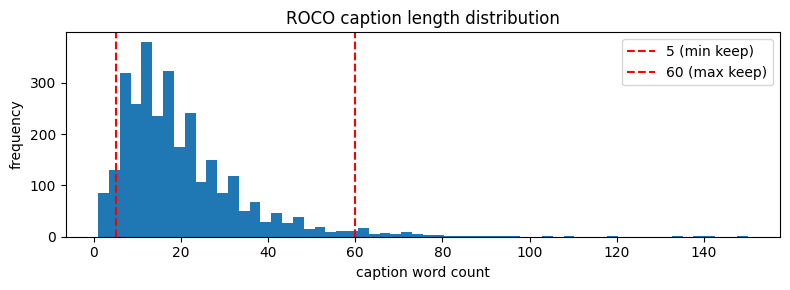


First image: type=PngImageFile, size=(704, 704), mode=RGB


In [11]:
# --- caption length distribution + image sanity check ---
import matplotlib.pyplot as plt

sample_n = min(3000, len(raw_ds[first_split]))
word_counts = [
    len(raw_ds[first_split][i][CAPTION_COL].split())
    for i in range(sample_n)
]
print(f"Caption word-count stats over {sample_n} samples:")
print(f"  min    = {min(word_counts)}")
print(f"  median = {int(np.median(word_counts))}")
print(f"  mean   = {np.mean(word_counts):.1f}")
print(f"  p95    = {int(np.percentile(word_counts, 95))}")
print(f"  max    = {max(word_counts)}")
print(f"  in 5-60 word window: "
      f"{sum(5 <= w <= 60 for w in word_counts):,} / {sample_n}")

plt.figure(figsize=(8,3))
plt.hist(word_counts, bins=60)
plt.xlabel("caption word count"); plt.ylabel("frequency")
plt.title("ROCO caption length distribution")
plt.axvline(5,  color="red", linestyle="--", label="5 (min keep)")
plt.axvline(60, color="red", linestyle="--", label="60 (max keep)")
plt.legend(); plt.tight_layout(); plt.show()

# image sanity
img0 = raw_ds[first_split][0][IMAGE_COL]
print(f"\nFirst image: type={type(img0).__name__}, size={img0.size}, mode={img0.mode}")

In [12]:
# --- decide splits: use native val/test if present, else split manually ---
split_keys = list(raw_ds.keys())
TRAIN_SPLIT = "train" if "train" in split_keys else split_keys[0]

val_candidates = [k for k in split_keys if k in ("validation", "valid", "val", "test")]
if val_candidates:
    VAL_SPLIT = val_candidates[0]
    use_manual_split = False
    print(f"Using native splits: train='{TRAIN_SPLIT}'  val='{VAL_SPLIT}'")
else:
    VAL_SPLIT = None
    use_manual_split = True
    print(f"No native val split. Will split '{TRAIN_SPLIT}' with seed={SEED}.")

Using native splits: train='train'  val='validation'


## 3. Filter captions and build train / val subsets

- Drop captions with <5 or >60 words
- Drop unreadable images
- Take 8,000 train and 1,000 val examples
- Deterministic with `seed=42`

In [13]:
TRAIN_SIZE = 8000
VAL_SIZE   = 1000
MIN_WORDS  = 5
MAX_WORDS  = 60

def caption_ok(ex):
    cap = ex.get(CAPTION_COL, "")
    if not isinstance(cap, str): return False
    n = len(cap.strip().split())
    return MIN_WORDS <= n <= MAX_WORDS

# Filter raw splits (ROCO captions have leading spaces / trailing \n)
train_pool = raw_ds[TRAIN_SPLIT].filter(caption_ok)
print(f"Filtered train pool: {len(train_pool):,}")

if use_manual_split:
    shuffled = train_pool.shuffle(seed=SEED)
    need = TRAIN_SIZE + VAL_SIZE
    assert len(shuffled) >= need, f"need {need}, have {len(shuffled)}"
    train_ds = shuffled.select(range(TRAIN_SIZE))
    val_ds   = shuffled.select(range(TRAIN_SIZE, need))
else:
    val_pool = raw_ds[VAL_SPLIT].filter(caption_ok)
    print(f"Filtered val pool:   {len(val_pool):,}")
    train_ds = train_pool.shuffle(seed=SEED).select(
        range(min(TRAIN_SIZE, len(train_pool)))
    )
    val_ds = val_pool.shuffle(seed=SEED).select(
        range(min(VAL_SIZE, len(val_pool)))
    )

print(f"\nFinal train: {len(train_ds):,}")
print(f"Final val:   {len(val_ds):,}")

Filter:   0%|          | 0/65419 [00:00<?, ? examples/s]

Filtered train pool: 60,729


Filter:   0%|          | 0/8175 [00:00<?, ? examples/s]

Filtered val pool:   7,606

Final train: 8,000
Final val:   1,000


## 4. Model, processor, and hyperparameters

All training hyperparameters live here. Nothing is hardcoded further down.

### Why these values
| param | value | reason |
|---|---|---|
| base model | `Salesforce/blip-image-captioning-base` | ~224M params, fits T4 comfortably |
| epochs | 5 | captions converge fast; more overfits 8k samples |
| batch size | 8 | fits fp16 BLIP-base in ~10 GB VRAM on T4 |
| grad accum | 4 | effective batch = 32, stable for captioning |
| lr | 5e-5 | standard BLIP fine-tuning LR |
| scheduler | cosine | smooth decay, no manual step |
| weight decay | 0.01 | AdamW default |
| grad clip | 1.0 | prevents rare loss spikes |
| max tgt len | 80 | covers >99% of filtered captions |
| fp16 | on | ~2x throughput, half the VRAM |
| freeze vision | toggle | decoder-only is faster; full usually scores higher |

In [14]:
# ============= HYPERPARAMETERS — edit here, nowhere else =============
MODEL_ID           = "Salesforce/blip-image-captioning-base"
FREEZE_VISION      = False      # True = decoder-only fine-tuning
EPOCHS             = 5
BATCH_SIZE         = 8          # drop to 4 if CUDA OOM
GRAD_ACCUM_STEPS   = 4          # effective batch = 32
LEARNING_RATE      = 5e-5
WEIGHT_DECAY       = 0.01
GRAD_CLIP          = 1.0
WARMUP_RATIO       = 0.05
MAX_TARGET_LEN     = 80
USE_FP16           = True
NUM_WORKERS        = 2
# =====================================================================

EFF_BATCH = BATCH_SIZE * GRAD_ACCUM_STEPS
print(f"Effective batch size: {EFF_BATCH}")
print(f"Fine-tuning mode:     "
      f"{'decoder-only (vision frozen)' if FREEZE_VISION else 'full'}")

Effective batch size: 32
Fine-tuning mode:     full


In [17]:
from transformers import BlipProcessor, BlipForConditionalGeneration

print(f"Loading {MODEL_ID} ...")
processor = BlipProcessor.from_pretrained(MODEL_ID)
model     = BlipForConditionalGeneration.from_pretrained(MODEL_ID)

if FREEZE_VISION:
    for p in model.vision_model.parameters():
        p.requires_grad = False
    print("Vision encoder frozen.")

device = torch.device("cuda")
model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable/1e6:.1f}M / {total/1e6:.1f}M "
      f"({100*trainable/total:.1f}%)")

Loading Salesforce/blip-image-captioning-base ...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Trainable params: 247.4M / 247.4M (100.0%)


## 5. Dataloader and collate function

The collate function calls the BLIP processor on a batch of PIL images +
captions. Labels with `pad_token_id` are masked with `-100` so loss
ignores padding.

In [18]:
from torch.utils.data import DataLoader

def blip_collate(batch):
    images   = [ex[IMAGE_COL].convert("RGB") for ex in batch]
    captions = [ex[CAPTION_COL].strip() for ex in batch]

    enc = processor(
        images=images,
        text=captions,
        padding="max_length",
        truncation=True,
        max_length=MAX_TARGET_LEN,
        return_tensors="pt",
    )
    labels = enc["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    enc["labels"] = labels
    return enc

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=blip_collate, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=blip_collate, pin_memory=True,
)
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Train batches: 1000
Val batches:   125


## 6. Training loop

- fp16 autocast + `GradScaler`
- Gradient accumulation over `GRAD_ACCUM_STEPS` mini-batches
- Cosine LR schedule with linear warmup
- Gradient clipping at 1.0
- **Checkpoint after every epoch** (Colab can disconnect)
- Best checkpoint (lowest val loss) is copied to `FINAL_MODEL`

In [19]:
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
import shutil, time, math

steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS)
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps,
)
scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)

print(f"Optimizer steps per epoch: {steps_per_epoch}")
print(f"Total optimizer steps:     {total_steps}")
print(f"Warmup steps:              {warmup_steps}")

Optimizer steps per epoch: 250
Total optimizer steps:     1250
Warmup steps:              62


/tmp/ipykernel_563/2483087817.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)


In [20]:
from tqdm.auto import tqdm

@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    tot, n = 0.0, 0
    for batch in tqdm(loader, desc="val", leave=False):
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        with torch.cuda.amp.autocast(enabled=USE_FP16):
            out = model(**batch)
        tot += out.loss.item() * batch["input_ids"].size(0)
        n   += batch["input_ids"].size(0)
    model.train()
    return tot / max(n, 1)

train_losses, val_losses = [], []
best_val = float("inf")
t_start = time.time()

try:
    for epoch in range(1, EPOCHS + 1):
        print(f"\n===== Epoch {epoch}/{EPOCHS} =====")
        model.train()
        running, seen = 0.0, 0
        optimizer.zero_grad(set_to_none=True)

        pbar = tqdm(train_loader, desc=f"train e{epoch}")
        for step, batch in enumerate(pbar):
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

            with torch.cuda.amp.autocast(enabled=USE_FP16):
                out = model(**batch)
                loss = out.loss / GRAD_ACCUM_STEPS

            scaler.scale(loss).backward()

            if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad],
                    GRAD_CLIP,
                )
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

            running += out.loss.item() * batch["input_ids"].size(0)
            seen    += batch["input_ids"].size(0)
            pbar.set_postfix(loss=f"{running/seen:.4f}",
                             lr=f"{scheduler.get_last_lr()[0]:.2e}")

        tr_loss = running / max(seen, 1)
        vl_loss = eval_loss(model, val_loader)
        train_losses.append(tr_loss); val_losses.append(vl_loss)
        print(f"epoch {epoch}: train={tr_loss:.4f}  val={vl_loss:.4f}")

        # --- always checkpoint (Colab may disconnect) ---
        ep_dir = f"{CKPT_DIR}/epoch_{epoch}"
        model.save_pretrained(ep_dir)
        processor.save_pretrained(ep_dir)
        print(f"checkpoint -> {ep_dir}")

        if vl_loss < best_val:
            best_val = vl_loss
            if os.path.exists(FINAL_MODEL):
                shutil.rmtree(FINAL_MODEL)
            shutil.copytree(ep_dir, FINAL_MODEL)
            print(f"new best val={vl_loss:.4f}  -> {FINAL_MODEL}")

except torch.cuda.OutOfMemoryError:
    print("\nCUDA OOM. Lower BATCH_SIZE to 4 (raise GRAD_ACCUM_STEPS to 8 to "
          "keep effective batch=32) and rerun the training cell.")
    raise

print(f"\nTotal train time: {(time.time()-t_start)/60:.1f} min")
print(f"Best val loss:    {best_val:.4f}")


===== Epoch 1/5 =====


train e1:   0%|          | 0/1000 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

/tmp/ipykernel_563/2218868198.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_FP16):
/tmp/ipykernel_563/2218868198.py:45: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


val:   0%|          | 0/125 [00:00<?, ?it/s]

...

train e5:   0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_563/2218868198.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_FP16):


val:   0%|          | 0/125 [00:00<?, ?it/s]

/tmp/ipykernel_563/2218868198.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_FP16):


epoch 5: train=2.0988  val=3.2236
checkpoint -> /content/blip_roco_outputs/checkpoints/epoch_5

Total train time: 51.8 min
Best val loss:    3.1908


## 7. Evaluation — pretrained vs fine-tuned

We generate captions on the **entire validation set** with
`num_beams=4` for both the original pretrained BLIP and the fine-tuned
checkpoint, then compute BLEU-4, METEOR, and BERTScore.

In [23]:
# free VRAM before loading a second copy of BLIP
import gc
for _name in ("optimizer", "scheduler", "scaler"):
    if _name in globals():
        del globals()[_name]
gc.collect(); torch.cuda.empty_cache()

print("Loading pretrained baseline ...")
pretrained = BlipForConditionalGeneration.from_pretrained(MODEL_ID).to(device)
pretrained.eval()

print(f"Loading fine-tuned from {FINAL_MODEL} ...")
finetuned = BlipForConditionalGeneration.from_pretrained(FINAL_MODEL).to(device)
finetuned.eval()


Loading pretrained baseline ...
Loading fine-tuned from /content/blip_roco_outputs/blip-roco-finetuned ...


BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

In [24]:
@torch.no_grad()
def generate_captions(model_, loader_ds, batch_size=8, num_beams=4, max_new_tokens=128):
    preds, refs, imgs = [], [], []
    model_.eval()
    for start in tqdm(range(0, len(loader_ds), batch_size), desc="generate"):
        chunk = [loader_ds[i] for i in range(start, min(start+batch_size, len(loader_ds)))]
        images   = [ex[IMAGE_COL].convert("RGB") for ex in chunk]
        captions = [ex[CAPTION_COL].strip() for ex in chunk]

        pv = processor(images=images, return_tensors="pt").to(device)
        with torch.cuda.amp.autocast(enabled=USE_FP16):
            out = model_.generate(
                **pv, num_beams=num_beams, max_new_tokens=max_new_tokens,
                early_stopping=True,
            )
        decoded = processor.batch_decode(out, skip_special_tokens=True)
        preds.extend([d.strip() for d in decoded])
        refs.extend(captions)
        imgs.extend(images)
    return preds, refs, imgs

print("Generating with pretrained ...")
pre_preds, refs, val_images = generate_captions(pretrained, val_ds)

print("Generating with fine-tuned ...")
ft_preds, _, _ = generate_captions(finetuned, val_ds)

print(f"Generated {len(pre_preds)} captions from each model.")

Generating with pretrained ...


generate:   0%|          | 0/125 [00:00<?, ?it/s]

/tmp/ipykernel_563/1873513163.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_FP16):


Generating with fine-tuned ...


generate:   0%|          | 0/125 [00:00<?, ?it/s]

Generated 1000 captions from each model.


In [25]:
import evaluate

bleu      = evaluate.load("bleu")
meteor    = evaluate.load("meteor")
bertscore = evaluate.load("bertscore")

def score_all(preds, refs):
    b = bleu.compute(predictions=preds, references=[[r] for r in refs], max_order=4)
    m = meteor.compute(predictions=preds, references=refs)
    bs = bertscore.compute(
        predictions=preds, references=refs,
        lang="en", model_type="distilbert-base-uncased",
        batch_size=16, device="cuda",
    )
    return {
        "BLEU-4":      b["bleu"],
        "METEOR":      m["meteor"],
        "BERTScore-F1": float(np.mean(bs["f1"])),
    }

print("Scoring pretrained ...")
pre_scores = score_all(pre_preds, refs)
print("Scoring fine-tuned ...")
ft_scores  = score_all(ft_preds, refs)

import pandas as pd
cmp_df = pd.DataFrame(
    {"Pretrained BLIP": pre_scores, "Fine-tuned BLIP": ft_scores}
).round(4)
cmp_df["delta"] = (cmp_df["Fine-tuned BLIP"] - cmp_df["Pretrained BLIP"]).round(4)
print("\n=== Metric comparison on validation set ===")
print(cmp_df)
cmp_df.to_csv(f"{OUT_DIR}/metrics.csv")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Scoring pretrained ...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Scoring fine-tuned ...

=== Metric comparison on validation set ===
              Pretrained BLIP  Fine-tuned BLIP   delta
BLEU-4                 0.0011           0.0324  0.0313
METEOR                 0.0347           0.1644  0.1297
BERTScore-F1           0.7041           0.7806  0.0765


## 8. Qualitative examples — pretrained vs fine-tuned side by side

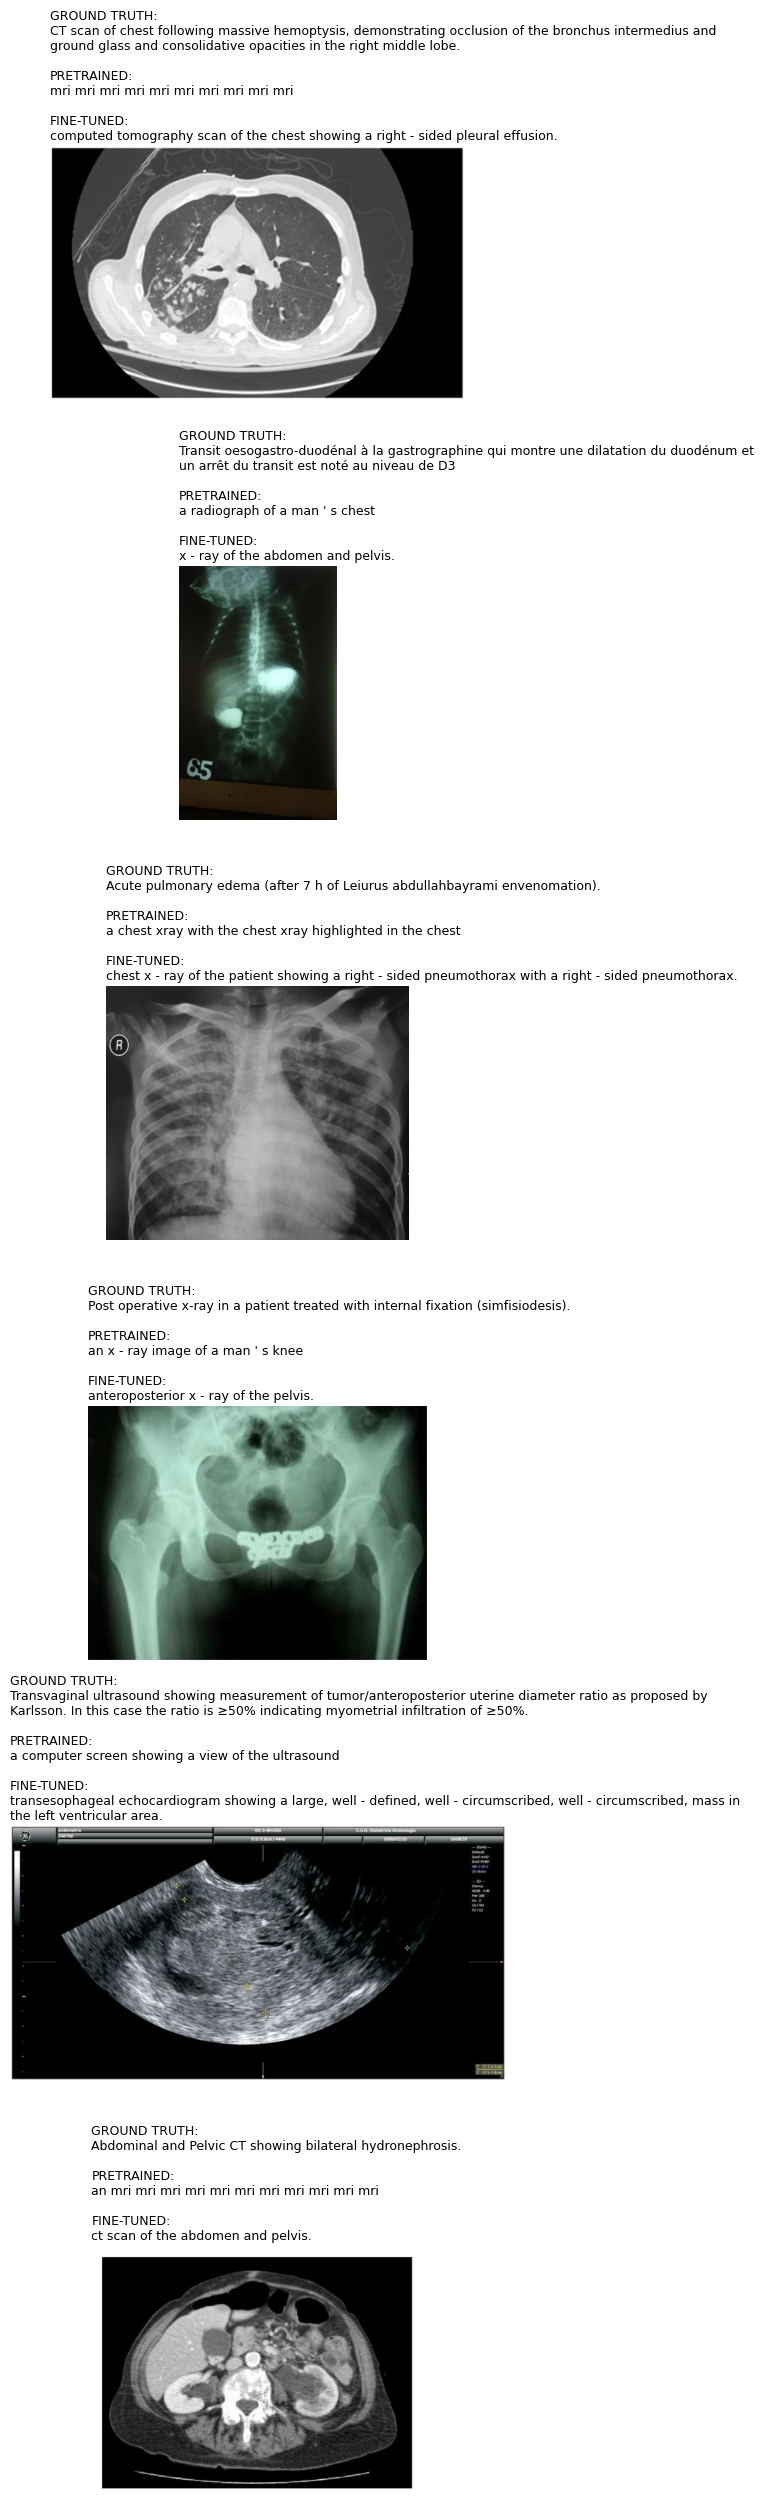

Saved /content/blip_roco_outputs/plots/qualitative_examples.png


In [26]:
import matplotlib.pyplot as plt

N_SHOW = 6
idxs = np.random.default_rng(SEED).choice(len(val_images), N_SHOW, replace=False)

fig, axes = plt.subplots(N_SHOW, 1, figsize=(10, 4.2*N_SHOW))
if N_SHOW == 1: axes = [axes]
for ax, i in zip(axes, idxs):
    ax.imshow(val_images[i], cmap="gray")
    ax.axis("off")
    txt = (f"GROUND TRUTH:\n{refs[i][:260]}\n\n"
           f"PRETRAINED:\n{pre_preds[i][:260]}\n\n"
           f"FINE-TUNED:\n{ft_preds[i][:260]}")
    ax.set_title(txt, loc="left", fontsize=9, wrap=True)

plt.tight_layout()
qpath = f"{PLOTS_DIR}/qualitative_examples.png"
plt.savefig(qpath, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved {qpath}")

## 9. Training / validation loss curves

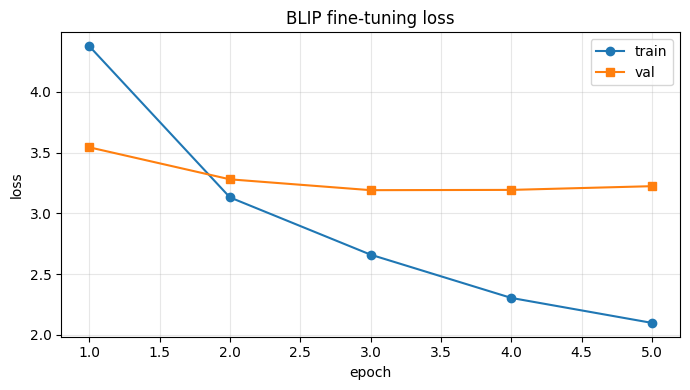

Saved /content/blip_roco_outputs/plots/loss_curves.png


In [27]:
plt.figure(figsize=(7,4))
ep = list(range(1, len(train_losses)+1))
plt.plot(ep, train_losses, marker="o", label="train")
plt.plot(ep, val_losses,   marker="s", label="val")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("BLIP fine-tuning loss")
plt.grid(alpha=0.3); plt.legend()
lpath = f"{PLOTS_DIR}/loss_curves.png"
plt.tight_layout(); plt.savefig(lpath, dpi=130); plt.show()
print(f"Saved {lpath}")

## 10. Package the fine-tuned model and download

The zip contains the HuggingFace model + processor, ready to load with

```python
from transformers import BlipProcessor, BlipForConditionalGeneration
processor = BlipProcessor.from_pretrained("blip-roco-finetuned")
model     = BlipForConditionalGeneration.from_pretrained("blip-roco-finetuned")
```

In [28]:
import shutil

print(f"Zipping {FINAL_MODEL} ...")
shutil.make_archive(ZIP_PATH.replace(".zip",""), "zip", FINAL_MODEL)
sz_mb = os.path.getsize(ZIP_PATH) / 1e6
print(f"Zip: {ZIP_PATH}  ({sz_mb:.1f} MB)")

# Small bundle of training artifacts (plots + metrics.csv). We
# intentionally DO NOT re-zip OUT_DIR here, because that directory
# contains the model zip above plus per-epoch checkpoints (multiple
# gigabytes of duplicated weights).
ARTIFACTS_DIR = f"{OUT_DIR}/_artifacts_staging"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
for src in (PLOTS_DIR, f"{OUT_DIR}/metrics.csv"):
    if os.path.isdir(src):
        shutil.copytree(src, f"{ARTIFACTS_DIR}/plots", dirs_exist_ok=True)
    elif os.path.isfile(src):
        shutil.copy(src, ARTIFACTS_DIR)

BUNDLE_ZIP = f"{OUT_DIR}/training_artifacts.zip"
shutil.make_archive(BUNDLE_ZIP.replace(".zip",""), "zip", ARTIFACTS_DIR)
shutil.rmtree(ARTIFACTS_DIR, ignore_errors=True)
art_mb = os.path.getsize(BUNDLE_ZIP) / 1e6
print(f"Artifacts bundle: {BUNDLE_ZIP}  ({art_mb:.2f} MB)")


Zipping /content/blip_roco_outputs/blip-roco-finetuned ...
Zip: /content/blip_roco_outputs/blip-roco-finetuned.zip  (917.7 MB)
Artifacts bundle: /content/blip_roco_outputs/training_artifacts.zip  (0.89 MB)


In [29]:
# --- trigger browser download to user's local machine ---
try:
    from google.colab import files
    print("Starting browser download of fine-tuned model zip ...")
    files.download(ZIP_PATH)
except Exception as e:
    print("files.download not available (not in Colab?):", e)
    print("Download manually from the file panel:", ZIP_PATH)

Starting browser download of fine-tuned model zip ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Optional: save to Google Drive

Uncomment the cell below if your Drive is mounted at `/content/drive`.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# import shutil
# dst = "/content/drive/MyDrive/blip-roco-finetuned.zip"
# shutil.copy(ZIP_PATH, dst)
# print("Copied to", dst)

---
### Summary

- Fine-tuned model dir: `/content/blip_roco_outputs/blip-roco-finetuned/`
- Zip for download: `/content/blip_roco_outputs/blip-roco-finetuned.zip`
- Loss curve: `/content/blip_roco_outputs/plots/loss_curves.png`
- Qualitative examples: `/content/blip_roco_outputs/plots/qualitative_examples.png`
- Metrics CSV: `/content/blip_roco_outputs/metrics.csv`

Deployment / demo is handled in a separate notebook.